In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')
print("✅ All libraries loaded!")

✅ All libraries loaded!


In [2]:
df = pd.read_csv('../data/dataset.csv')
df['content'] = df['title'].fillna('') + " " + df['text'].fillna('')
print(f"Total articles: {len(df)}")
print(f"Real: {(df['label']==0).sum()}")
print(f"Fake: {(df['label']==1).sum()}")
df.head()

Total articles: 44898
Real: 21417
Fake: 23481


,title,text,label,content
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,"Donald Trump s White House is in chaos, and th...",1,BREAKING: GOP Chairman Grassley Has Had Enoug...
1,Failed GOP Candidates Remembered In Hilarious...,Now that Donald Trump is the presumptive GOP n...,1,Failed GOP Candidates Remembered In Hilarious...
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,Mike Pence is a huge homophobe. He supports ex...,1,Mike Pence’s New DC Neighbors Are HILARIOUSLY...
3,California AG pledges to defend birth control ...,SAN FRANCISCO (Reuters) - California Attorney ...,0,California AG pledges to defend birth control ...
4,AZ RANCHERS Living On US-Mexico Border Destroy...,Twisted reasoning is all that comes from Pelos...,1,AZ RANCHERS Living On US-Mexico Border Destroy...


FileNotFoundError: [Errno 2] No such file or directory: '../assets/distribution.png'

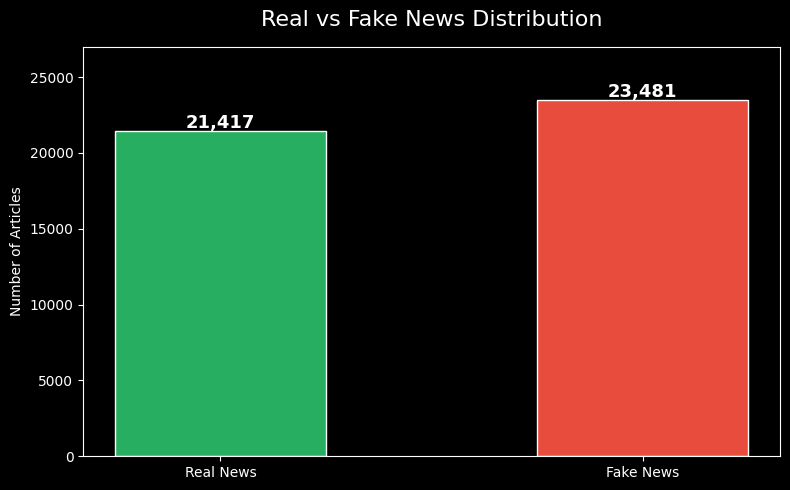

In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
counts = df['label'].value_counts()
bars = ax.bar(['Real News', 'Fake News'], 
               [counts[0], counts[1]], 
               color=['#27ae60', '#e74c3c'], 
               width=0.5, edgecolor='white')

for bar, count in zip(bars, [counts[0], counts[1]]):
    ax.text(bar.get_x() + bar.get_width()/2, 
            bar.get_height() + 200,
            f'{count:,}', ha='center', 
            fontsize=13, color='white', fontweight='bold')

ax.set_title('Real vs Fake News Distribution', fontsize=16, pad=15)
ax.set_ylabel('Number of Articles')
ax.set_ylim(0, 27000)
plt.tight_layout()
plt.savefig('../assets/distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")

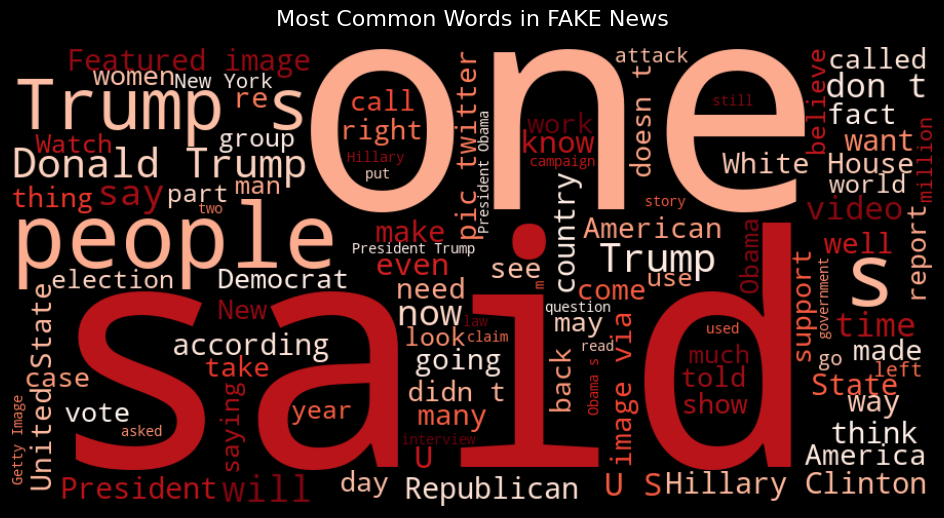

✅ Word cloud saved!


In [4]:
import os
os.makedirs('../assets', exist_ok=True)

fake_text = ' '.join(df[df['label']==1]['content'].dropna().tolist())
wc = WordCloud(width=900, height=450, 
               background_color='black',
               colormap='Reds',
               max_words=100).generate(fake_text)

plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in FAKE News', fontsize=16, pad=15)
plt.savefig('../assets/wordcloud_fake.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Word cloud saved!")

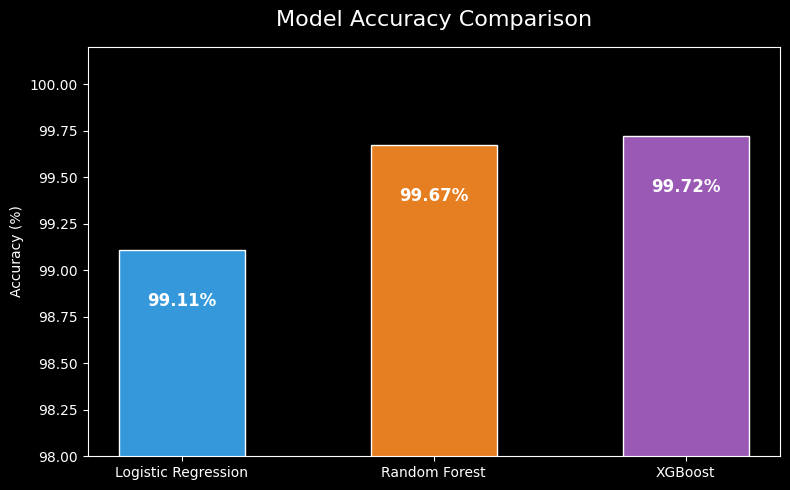

✅ Comparison chart saved!


In [5]:
results = pd.read_csv('../model/saved/model_comparison.csv')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db', '#e67e22', '#9b59b6']
bars = ax.bar(results['Model'], results['Accuracy'], 
               color=colors, width=0.5, edgecolor='white')

for bar, acc in zip(bars, results['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() - 0.3,
            f'{acc}%', ha='center',
            fontsize=12, color='white', fontweight='bold')

ax.set_title('Model Accuracy Comparison', fontsize=16, pad=15)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(98, 100.2)
plt.tight_layout()
plt.savefig('../assets/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved!")